## Weakly Supervised Semantic Segmentation

## Abstract

In this project, we explore the topic of weakly supervised semantic segmentation (WSSS) with image level labels. We use much of the same methodology in dataset construction, training and validation as in assignment 5. However, compared to fully supervised semantic segmentation, training on only image labels is much more difficult as there is no ground truth segmentation mask to compare with. In this project, we mainly explore different loss functions for WSSS, but also consider other factors such as hyperparameters and the model architecture itself.

For the neural network, we use a pretrained backbone from DinoV3 and add convolutional and fully connected layers to it for classification. The model will be trained on the Pascal VOC 2012 dataset.

## Team Members and Contributions:
Daniel Chen (y549chen@uwaterloo.ca) 
- Functions for visualization of results
- DinoV3 model implementation
- Loss Functions

John Jiang (j342jian@uwaterloo.ca)
- Dataset construction and transforms
- Loss Functions
- Model Training
- Model validation and miou calculation

## Libraries Used
- Torch, TorchVision, TorchMetrics: used for constructing and training the neural network
- MatPlotLib: used for visualizing results
- NumPy: used for various calculations
- PIL: used to colourize the segmentation mask
- dotenv: secure storage of variables

these can all be installed by running the command
```
pip install requirements.txt
```

## Implementation

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as tF

import copy
import random

In [73]:
USE_GPU = True
device = torch.device('cuda' if USE_GPU and torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


We chose to train our model on the PASCAL VOC 2012 dataset. From our research, it appears to a popular reliable dataset that is not too large or complicated. It also has the image labels required for WSSS and ground truth segmentations that we can use to evalute performance.

In [74]:
# load the 'train' dataset from Pascal VOC 2012
dataset = torchvision.datasets.VOCDetection(root='./data', year='2012', image_set='train', download=False)
NUM_CLASSES = 21
VOC_CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor"
]

Some helper functions that will be useful later.

In [75]:
# Extract label multi-hot tensor from image data
def extract_label_mask(data):
    class_to_idx = {cls: i for i, cls in enumerate(VOC_CLASSES)}
    mask = torch.zeros(len(VOC_CLASSES), dtype=bool)

    objects = data.get('annotation', {}).get('object', [])

    if isinstance(objects, dict):
        objects = [objects]

    for obj in objects:
        cls_name = obj.get('name')

        # set present classes to True in the mask
        if isinstance(cls_name, list):
            for c in cls_name:
                if c in class_to_idx:
                    mask[class_to_idx[c]] = True
            continue

        if isinstance(cls_name, str):
            if cls_name in class_to_idx:
                mask[class_to_idx[cls_name]] = True
                
    mask[0] = 1 # background is always present
    return mask

In [76]:
# function for displaying the bounding boxes on an image
def show_bounding_box(figure, target):
  for obj in target['annotation']['object']:
    x, y, x2, y2 = [int(i) for i in obj['bndbox'].values()]
    w = x2 - x
    h = y2 - y

    rect = patches.Rectangle(
      (x, y), w, h,
      linewidth=2,
      edgecolor='red',
      facecolor='none'
    )

    figure.add_patch(rect)

    # Add class name to box
    figure.text(
        x, y - 0.02,         
        obj['name'],
        color='red',
        fontsize=12,
        verticalalignment='bottom',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
    )

## Transforms
We construct several transforms that will be used for preprocessing the input images before they are passed into the network. For normalization, we took the mean and std values suggested by the official DinoV3 documentation. When cropping, we chose the size of 256 by 256 pixel patch. This size is large enough to retain most of the classes present in the image.

In [77]:
import torchvision
from torchvision.transforms import v2

sanity_transforms = transforms.Compose([
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

preprocess_transforms = transforms.Compose([
    transforms.RandomResizedCrop(256, (0.5, 1.5)),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((256, 256), antialias=True),
    transforms.ToTensor()
])

train_transforms = transforms.Compose([
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Dataset Construction
Here, we construct 3 datasets for training with different sizes. The sanity dataset the smallest, and is meant to act as a quick check to see if the model is running. The test dataset is larger with 200 images so we can see if the model produces reasonable results before training on the full "train" dataset.

Since the sanity dataset is so small, we filter the images to make sure they have the same classes present.

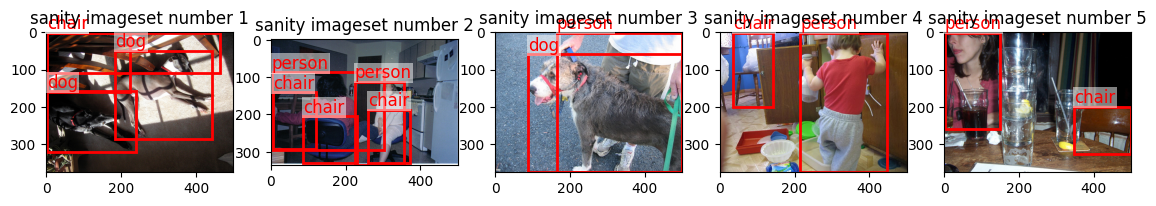

In [78]:
sanity_data = []
sanity_objects = {'person', 'chair', 'dog'}
for data in dataset:
    objects = data[1]['annotation']['object']
    obj_set = set()
    
    for obj in objects:
        obj_set.add(obj['name'])
    
    if sanity_objects.issuperset(obj_set) and len(obj_set) > 1:
        sanity_data.append(data)
    
    if len(sanity_data) >= 16:
        break

# visualize the sanity imageset
fig = plt.figure(figsize=(14,10))
for i in range(1, 6):
    img, target = sanity_data[i-1]

    ax = fig.add_subplot(1,5,i)
    plt.title(f'sanity imageset number {i}')
    ax.imshow(img)
    show_bounding_box(ax, target)

In [79]:
from torch.utils.data import Dataset, DataLoader, Subset

class myDataset(Dataset):
  def __init__(self, dataset, transform=sanity_transforms):
    self.data = dataset
    self.transform = transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    img, target = self.data[idx]

    # Preprocess images
    if self.transform:
        img = preprocess_transforms(img)
        altered_img = self.transform(img)

    labels = extract_label_mask(target)

    return altered_img, labels, img

TRAIN_BATCH_SIZE = 8
sanity_dataset = myDataset(sanity_data, sanity_transforms)
test_dataset = myDataset(Subset(dataset, range(800)), train_transforms)
train_dataset = myDataset(dataset, train_transforms)

sanity_loader = DataLoader(sanity_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)

Our network takes approximately 35 minutes to train (for 10 epochs) on the full training dataset on our machines. This was too slow, so we created smaller test datasets. 

In practice, the overfit net trained on the small dataset was not very useful. While it took little time to train, the sparseness of the data made it difficult to discern if our changes had any meaningful effect. 

For testing purposes, we found that the test net trained on a larger subset of the full training data was better. It took approximately 5 minutes to train (for 10 epochs) on our machines and produced decent results. Further, there were clear and consistent effects when we changed our network or losses. 

## Model Construction
For the backbone, we are using the pretrained DinoV3 ViT-S/16 model. It can be found at https://github.com/facebookresearch/dinov3

In [80]:
import os 
from dotenv import load_dotenv
load_dotenv()

# load the DINOv3 ViT-S/16 backbone with pretrained weights
backbone_url = os.getenv("BACKBONE_URL")
dino_backbone = torch.hub.load(
    "facebookresearch/dinov3",
    "dinov3_vits16",
    source="github",
    weights=backbone_url
)

print(dino_backbone)

dino_backbone.to(device)

Using cache found in /Users/danielchen/.cache/torch/hub/facebookresearch_dinov3_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

Here is our CNN architecture that we will be using. It consists of the DinoV3 backbone, then two additional trainable convolution layers, a bilinear upsampling to restore original image resolution, and finally a fully connected layer. The outputs are not converted to probabilities through softmax as this is easier for training. Note that we chose to freeze the weights in the backbone as the feature representation should already be quite good and this also lowers the total number of trainable weights.

In [81]:
class DinoNuggets(nn.Module):
  def __init__(self, backbone, num_classes, freeze=True, embed_dim=384):
    super(DinoNuggets, self).__init__()
    self.backbone = backbone
    self.backbone_patch_size = 16

    # Freeze backbone weights
    if freeze:
      for name, param in self.backbone.named_parameters():
        param.requires_grad = False
    else:
      for name, param in self.backbone.named_parameters():
        param.requires_grad = True

    self.conv_1 = nn.Sequential(
      nn.Conv2d(embed_dim, 256, kernel_size=3, padding=1, bias=False),
      nn.ReLU(inplace=True),
    )

    self.conv_2 = nn.Sequential(
      nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
      nn.ReLU(inplace=True),
    )

    self.final = nn.Conv2d(256, num_classes, kernel_size=(1, 1))

  def forward(self, x):
    B, _, H, W = x.shape

    x0 = self.backbone.get_intermediate_layers(
        x, n=1, reshape=True, return_class_token=False, norm=True
    )[0]

    # CNN Layers
    x1 = self.conv_1(x0)
    x2 = self.conv_2(x1)

    features = x2

    # Scale up features and predictions
    features_up = F.interpolate(
        features, size=(H, W), mode="bilinear", align_corners=False
    )
    x2_up = F.interpolate(
        x2, size=(H, W), mode="bilinear", align_corners=False
    )

    xfinal = self.final(x2_up)

    if self.training:
        return xfinal, features_up

    return xfinal

Originally, we had 3 intermediate convolution layers. Through testing, we found that the inclusion of a third layer did not meaningfully affect the MIoU. We thus concluded that 2 layers was enough the represent the complexity of the task and that a third might lead to overfitting.

Some more helper functions for better visualization

In [82]:
from PIL import Image, ImageOps

# Define colour palette for visualization of segmentation
palette = [0, 0, 0, 128, 0, 0, 0, 128, 0, 128, 128, 0, 0, 0, 128, 128, 0, 128, 0, 128, 128,
           128, 128, 128, 64, 0, 0, 192, 0, 0, 64, 128, 0, 192, 128, 0, 64, 0, 128, 192, 0, 128,
           64, 128, 128, 192, 128, 128, 0, 64, 0, 128, 64, 0, 0, 192, 0, 128, 192, 0, 0, 64, 128]

def colorize_mask(mask):
    new_mask = Image.fromarray(mask.astype(np.uint8)).convert('P')
    new_mask.putpalette(palette)

    return new_mask

In [83]:
# function that visualizes the CAM for a specific class
def show_CAM(net, imageset, class_id, sample_id, normalize=True):
    net.eval()
    
    img, _ = imageset[sample_id]
    
    # Extract CAM predictions
    output = net.forward(sanity_transforms(img).unsqueeze(0).to(device))
    cam = torch.sigmoid(output[0, class_id])  # (H, W)

    if normalize:
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-5)

    cam = cam.detach().cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title(f"CAM - class {class_id}")
    plt.axis('off')
    plt.show()

## Loss Functions

In this section, we introduce the various loss functions that we will experiment with, including the motivation, derivation and implementation.

### Tag Consistency Loss

This is the loss function that was suggested in the lecture notes for weakly semantic segmentation. Formally, define the predicted class probabilities at pixel $p$ to be $\sigma^p = (\sigma_0^p, \ldots, \sigma_{20}^p)$. The tag consistency loss for a single image is given by
$$L_{tc}(W) = -\sum_{p} \ln \left( \sum_{k \in T} \sigma^p_T \right)$$
where $T$ is the set of ground truth class labels of the image. Essentially, this loss encourages the model to suppress probabilities assigned to classes that are not present in the image.

In [ ]:
def tag_loss(result, target):
    # result: size (B, C, H, W), logits
    # target: size (B, C), multi-hot ground truth tensors from dataset

    class_mask = target.to(result.device).bool()
    log_probs = F.softmax(result, dim=1)  

    # Mask out absent classes
    mask = class_mask[:, :, None, None]
    masked_log_probs = log_probs.masked_fill(~mask, float('-inf'))

    # Compute loss
    pixel_log_prob = torch.logsumexp(masked_log_probs, dim=1)
    loss = -pixel_log_prob.mean()
    return loss

### Background Loss
This loss simply penalizes classifying pixels as the background. In some cases, this can help prevent the model from degenerating to an all-background solution. The loss is given by
$$L_{bg}(W) = \left(\frac{w_b}{n} \sum_{p} \sigma^p_0 \right)^2$$
where $w_b$ is a hyperparameter that controls how much penalty we give to background pixels. We define $n$ to be the total number of pixels in the image. Note that the penalty is quadratic in the mean probability assigned to background as we want to strongly discourage the case when a large part of the image is classified as background.

In [ ]:
def bg_loss(result, bg_weight):
    bg_idx = 0 
    probs = torch.softmax(result, dim=1)
    bg_prob = probs[:, bg_idx, :, :]

    bg_loss = bg_prob.mean()
    loss =  (bg_weight * bg_loss)**2
    return loss

### Seeding Loss
This loss is based on the idea from the paper by Kolesnikov and Lampert [1] - see citations section. The idea is that we extract the probability CAM maps for the classes present in the image and see where the model is confident. For those regions, we add an NLL loss to encourage the model to treat those as seeds from which to generate the full objects. Formally, let $t$ be a hyperparameter for the threshold for which we consider a prediction to be strong enough to use as a seed. Let the sets $S_1, \ldots S_{20}$ be the confident pixels for the foreground class. The loss is then
$$ L_{seed}(W, t) = - \frac{1}{\sum_{i=1}^{20} |S_i|} \sum_{i=1}^{20} \sum_{p \in S_i} \ln \sigma^p_{i} $$
which is essentially the average NLL loss at all confident pixels. Note that this loss is low when $\sigma^p_i$ is high, which corresponds to the model being more confident at pixel $p$.

In [ ]:
def seed_loss(result, target, threshold=0.6):
    B, C, _, _ = result.shape

    # get CAM maps
    cams = torch.sigmoid(result)  # (B, C, H, W)
    cams = cams * target.unsqueeze(-1).unsqueeze(-1)

    # normalize CAMs for each class
    cams_flat = cams.view(B, C, -1)
    cam_min = cams_flat.min(dim=-1)[0].view(B, C, 1, 1)
    cam_max = cams_flat.max(dim=-1)[0].view(B, C, 1, 1)
    cams = (cams - cam_min) / (cam_max - cam_min + 1e-5)

    # select confident pixels
    max_vals, pseudo_labels = cams.max(dim=1)
    mask = max_vals > threshold 

    if mask.sum() == 0:
        return torch.tensor(0.0, device=result.device, requires_grad=True)

    # compute loss
    log_probs = F.log_softmax(result, dim=1)
    nll = -log_probs.gather(1, pseudo_labels.unsqueeze(1)).squeeze(1)
    loss = nll[mask].mean()
    return loss

### Average and Maximum Global Pooling
These are ideas taken from papers [2], [3]. This loss makes use of the image level labels available to us and performs a cross entropy between the ground truth and predicted labels. Average and maximum global pooling methods differ in that maximum takes only the maximally activated pixel for each class, whereas average global pooling takes the average activation over all image pixels. Formally, for a class $c$, we have either
$$f(c) = \max_{p} \sigma^p_c \qquad \text{or} \qquad f(c) = \frac{1}{n} \sum_p \sigma^p_c$$
Then, defining $F(W) = (f(0), \ldots, f(20))$, the loss is given by 
$$L_{pool}(W) = H(F(W), L)$$
where $H(p,q)$ is the cross entropy function and $L$ is indicator vector for ground truth labels. According to [1], maximum global pooling tends to estimate object regions to be smaller as it only cares about the maximum whereas average global pooling tends to make larger area estimates to increase the average.

In [ ]:
def global_max_pool_loss(result, target):
    # Convert logits to probabilities
    processed = torch.softmax(result, dim=1)
    pooled = torch.amax(processed, dim=(2, 3))
    
    loss = F.binary_cross_entropy(pooled, target.float())
    return loss

def global_avg_pool_loss(result, target):
    processed = torch.softmax(result, dim=1)
    pooled = torch.mean(processed, dim=(2, 3))
    
    loss = F.binary_cross_entropy(pooled, target.float())
    return loss

### Regularization Loss
This loss is based on ideas from the lecture on WSSS in this course. The idea is that pixels which are similar in RGBXY space in the original image should be assigned the same class. For efficiency, we only consider a sparsely connected graph by taking neighbours in a $k \times k$ kernel around each pixel $p$, denoted as $K_p$. The loss is then
$$L_{reg}(W) = \sum_{p} \sum_{q \in K_p} w_{pq} ||\sigma^p - \sigma^q||^2$$
where $w_{pq}$ is an edge weight based on a gaussian distribution. In particular,
$$w_{pq} = \operatorname{exp}\left\{ -\frac{d(p,q)^2}{2 \sigma_{xy}^2} -\frac{||I_p - I_q||^2}{2 \sigma_{rgb}^2} \right\}$$
where $d(p, q)$ denotes the Euclidean distance between the pixels and $I_p, I_q$ are the RGB values at $p, q$ respectively. Note that we have separate hyperparameters $\sigma_{xy}$ and $\sigma_{rgb}$ for distance and colour. This is because the range of colours will be much larger than distances and also yields distinct information, so we account for this difference.

In [ ]:
def regularization_loss(result, image, sigma_xy=3.0, sigma_rgb=10.0, kernel_size=3):
    B, C, H, W = result.shape

    probs = F.softmax(result, dim=1)
    pad = kernel_size // 2

    # compute squared differences for probabilities
    probs_unfold = F.unfold(probs, kernel_size, padding=pad)
    probs_unfold = probs_unfold.view(B, C, kernel_size*kernel_size, H, W)
    probs_center = probs.unsqueeze(2) 
    prob_diff = (probs_center - probs_unfold).pow(2).sum(dim=1) 

    # compute squared differences for RGB values
    image_unfold = F.unfold(image, kernel_size, padding=pad) 
    image_unfold = image_unfold.view(B, 3, kernel_size*kernel_size, H, W)
    image_center = image.unsqueeze(2) 
    color_diff = (image_center - image_unfold).pow(2).sum(dim=1)

    # compute distances in kernel grid 
    coords = torch.stack(torch.meshgrid(
        torch.arange(kernel_size),
        torch.arange(kernel_size),
        indexing="ij"
    ), dim=-1).float().to(result.device)

    coords = coords - kernel_size // 2
    spatial_dist = (coords[..., 0]**2 + coords[..., 1]**2).view(1, -1, 1, 1)

    # compute weights
    spatial_kernel = torch.exp(-spatial_dist / (2 * sigma_xy**2))  # (1, K*K, 1, 1)
    bilateral_kernel = spatial_kernel * torch.exp(-color_diff / (2 * sigma_rgb**2))

    # total loss
    loss = (bilateral_kernel * prob_diff).mean()
    return loss

### Max Area Regularization Loss
A common issue we ran into was that a class would often flood the image and far exceed its expected boundaries, sometimes even taking over the entire image. We thus discourage large areas in an attempt to have activation only in the most confident regions. The loss is
$$
L_{maxArea}(W, L) = \frac{1}{|L|} \sum_{l \in L} \max\left\{ 0, \sum_{p} \sigma^p_l - \alpha \right\},
$$
where $L$ is the set of present classes (excluding background) and $\alpha$ is a threshold hyperparameter. Essentially, it applies a linear penalty when a class's area exceeds the threshold proportion of the image, and average over the classes. We chose $\alpha = 0.3$ because, from inspecting the dataset, we felt that a class exceeding about a third of the image was rare.

In [ ]:
def max_area_constraint_loss(result, target, alpha=0.3):
    probs = torch.softmax(result, dim=1)  # (B, C, H, W)

    # ignore background (index 0)
    probs_fg = probs[:, 1:]
    target_fg = target[:, 1:].to(result.device).bool()

    # compute spatial mean per class
    area = probs_fg.mean(dim=(2, 3))

    # only apply to present classes
    area = area[target_fg]

    if area.numel() == 0:
        return torch.tensor(0.0, device=result.device)
    loss = torch.relu(area - alpha).mean()

    return loss

### Min Area Regularization Loss
This is similar to the max area regularization loss, but instead we penalize for a class appearing not enough. Some objects in the images are small, and the network would frequently miss them. We hoped that this loss would mitigate this effect. The loss is
$$
L_{maxArea}(W, L) = \frac{1}{|L|} \sum_{l \in L} \max\left\{ 0, \beta - \sum_{p} \sigma^p_l \right\},
$$
where $L$ is the set of present classes (excluding background) and $\beta$ is a threshold hyperparameter. It applies a linear penalty when a class's area is under the threshold proportion of the image, and average over the classes.

In [ ]:
def min_area_constraint_loss(result, target, beta=0.02):
    probs = torch.softmax(result, dim=1)

    # ignore background (index 0)
    probs_fg = probs[:, 1:]
    target_fg = target[:, 1:].to(result.device).bool()
    
    # spatial mean per class
    area = probs_fg.mean(dim=(2, 3))

    # select only present classes
    present_area = area[target_fg]

    if present_area.numel() == 0:
        return torch.tensor(0.0, device=result.device)
    loss = torch.relu(beta - present_area).mean()

    return loss

These are the final set of losses we used along with their scaling hyper-parameters. 

In [ ]:
TAG_COEF = 0.1
SEED_COEF = 1.0
AVG_POOLING_COEF = 2.0
MAX_POOLING_COEF = 2.0
SPACE_COEF = 1.0
MAX_AREA_COEF = 0.5

def loss(result, features, target, image):
    loss = 0
    loss += TAG_COEF * tag_loss(result, target, 1.0)
    loss += SEED_COEF * seed_loss(result, target, threshold=0.7)
    loss += AVG_POOLING_COEF * global_avg_pool_loss(result, target)
    loss += MAX_POOLING_COEF * global_max_pool_loss(result, target)
    loss += SPACE_COEF * regularization_loss(result, image)
    loss += MAX_AREA_COEF * max_area_constraint_loss(result, target, alpha=0.3)
    return loss

Note that we did not include the min area regularization loss. 

We added min area regularization loss to detect small objects in the image, which would either not be detected or have strange shapes. However, tuning the beta parameter was difficult and the results were often strange. The class would appear somewhere, but often not in the correct location. Further, there was no shape-regularization effect that we hoped for. As a result, we took it out.

We also experimented with more sophisticated losses that used the forward attention from the backbone or deep features from one of the intermediate convolution layers. One example was a contrastive loss that took a sample of pixels, computed their dot product similarity, and returned the infoNCE loss. We found that these approaches were not very effective in testing and often hurt our final validation score.

## Total Losses
In this section, we propose several paradigms for the overall loss of the model. Later, we will test each of them and compare the results.

### Loss 1
This loss is a combination of several important losses and is the first combination for which we actually got decent results. Here are some of the design decisions that we made regarding the losses, weighting, and hyperparameters:

- Overall, we use tag consistency loss and global pooling losses to ensure alignment with image labels, regularization loss for accurate object masks, and seed loss for good localization
- Both global pooling losses are used to try to balance their effects of overestimating and underestimating object areas
- We found that labels are not entirely correct in the dataset. For instance, some examples may contain a person, but it will not be labelled. The losses for tag consistency and background are assigned lower weights to try to minimize the influence this inaccuracy has on training
- Kernel size is set to the lowest possible value of 3 to reduce training time
- The deviation for RGB values is set to be higher since RGB values have a larger range and are generally farther apart

In [ ]:
def loss1(result, features, target, image):
    # loss weights
    TAG_COEF = 0.1
    BG_COEF = 0.1
    SEED_COEF = 2.0
    AVG_POOLING_COEF = 1.0
    MAX_POOLING_COEF = 1.0
    REG_COEF = 1.0
    
    # hyperparameters
    BG_WEIGHT = 1.0
    SEED_THRESHOLD = 0.7
    SIGMA_XY = 3.0
    SIGMA_RGB = 10.0
    KERNEL_SIZE = 3

    loss = 0
    loss += TAG_COEF * tag_loss(result, target)
    loss += BG_COEF * bg_loss(result, bg_weight=BG_WEIGHT)
    loss += SEED_COEF * seed_loss(result, target, threshold=SEED_THRESHOLD)
    loss += AVG_POOLING_COEF * global_avg_pool_loss(result, target)
    loss += MAX_POOLING_COEF * global_max_pool_loss(result, target)
    loss += REG_COEF * regularization_loss(result, image, SIGMA_XY, SIGMA_RGB, KERNEL_SIZE)
    return loss

In [ ]:
def loss2(result, features, target, image):
    TAG_COEF = 0.1
    BG_COEF = 0.1
    SEED_COEF = 1.0
    AVG_POOLING_COEF = 2.0
    MAX_POOLING_COEF = 2.0
    SPACE_COEF = 1.0
    MAX_AREA_COEF = 0.5
    
    loss = 0
    loss += TAG_COEF * tag_loss(result, target)
    loss += BG_COEF * bg_loss(result, bg_weight=1.0)
    loss += SEED_COEF * seed_loss(result, target, threshold=0.7)
    loss += AVG_POOLING_COEF * global_avg_pool_loss(result, target)
    loss += MAX_POOLING_COEF * global_max_pool_loss(result, target)
    loss += SPACE_COEF * regularization_loss(result, image)
    loss += MAX_AREA_COEF * max_area_constraint_loss(result, target, alpha=0.3)
    return loss

## Training
Now, we will train the models on our dataset. This is very similar to the process used in Assignment 5. We chose to use adam optimizer.

In [ ]:
def get_optimizer(net):
    optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)
    return optimizer

In [ ]:
# main training loop for one epoch 
def train(train_loader, net, optimizer, loss_graph, criterion = loss):

    net.train()
    total_loss = 0

    for i, data in enumerate(train_loader):

        inputs, target, img = data
        inputs = inputs.to(device)
        target = target.to(device)
        img = img.to(device)

        optimizer.zero_grad()

        outputs, features = net.forward(inputs)
        loss = criterion(outputs, features, target, img)
        loss.backward()
        optimizer.step()

        total_loss += loss

        loss_graph.append(loss.item())

    # Return the value of loss (averaged over the loaded data)
    val_loss = total_loss / len(train_loader)
    return val_loss

We define a few more functions for training and display of results.

In [84]:
# function that runs training and displays training loss
def run_training(net, num_epochs, loader):
    optimizer = get_optimizer(net)
    print("Starting Training...")

    loss_graph = []

    fig = plt.figure(figsize=(12,6))
    plt.subplots_adjust(bottom=0.2,right=0.85,top=0.95)
    ax = fig.add_subplot(1,1,1)

    for e in range(num_epochs):
        loss = train(loader, net, optimizer, loss_graph)
        
        ax.clear()
        ax.set_xlabel('iterations')
        ax.set_ylabel('loss value')
        ax.set_title('Training loss curve for net')
        ax.plot(loss_graph, label='training loss')
        ax.legend(loc='upper right')
        fig.canvas.draw()
        print("Epoch: {} Loss: {}".format(e, loss))

In [85]:
# shows the prediction result for a specific image
def show_training_results(net, index, imageset):
    net.eval()
    
    img, img_data = imageset[index]
    
    # get prediction
    output = net.forward(sanity_transforms(img).unsqueeze(0).to(device))

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(1, 2, 1)
    plt.title('image sample')
    ax.imshow(img)
    show_bounding_box(ax, img_data)

    ax = fig.add_subplot(1, 2, 2)
    plt.title('network output/prediction')

    # display segmentation mask with colorized labels
    segmentation_mask = torch.argmax(output, dim=1).cpu().numpy()[0]
    ax.imshow(colorize_mask(segmentation_mask))

    # add a legend for the present classes
    from matplotlib.lines import Line2D
    unique_labels = np.unique(segmentation_mask)
    legend_elements = [
        Line2D([0], [0], color=np.array(palette[label * 3:label * 3 + 3]) / 255, lw=4, label=VOC_CLASSES[label])
        for label in unique_labels if label < len(VOC_CLASSES)
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1))

Now, we actually train the model on our datasets.

In [ ]:
untrained_net = DinoNuggets(dino_backbone, NUM_CLASSES).to(device).eval()
overfit_net = copy.deepcopy(untrained_net).to(device)
run_training(overfit_net, num_epochs=20, loader=sanity_loader)

In [ ]:
# display untrained model output on sample image
sample_index = 4
show_training_results(untrained_net, index=sample_index, imageset=sanity_data)

In [ ]:
# show results from sanity dataset
sample_index = 4
show_training_results(overfit_net, index=sample_index, imageset=sanity_data)

In [ ]:
# train on larger test dataset
test_net = copy.deepcopy(untrained_net).to(device)
run_training(test_net, num_epochs=10, loader=test_loader)

In [ ]:
# try test model on sample image
sample_index = 4
show_training_results(test_net, index=sample_index, imageset=dataset)

In [ ]:
# training on full dataset
big_net = copy.deepcopy(untrained_net).to(device)
run_training(big_net, num_epochs=4, loader=train_loader)

In [ ]:
# test overall model on sample image
sample_index = 4
show_training_results(big_net, index=124, imageset=dataset)

## Evaluation
We judge how well our model performs using the Mean Intersection over Union (MIoU) metric. For this part, we use the validation dataset from Pascal VOC 2012 which is not part of the training set. The images are resized to size 256 by 256 so they can be stacked as tensors.

In [ ]:
# define image transform for validation
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)), 
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# transform mask also
def target_transform(mask):
    mask = transforms.Resize(
        (256, 256),
        interpolation=transforms.InterpolationMode.NEAREST
    )(mask)
    return torch.as_tensor(np.array(mask), dtype=torch.long)

# fetch validation dataset
# ...existing code...
val_data = torchvision.datasets.VOCSegmentation(
    root="./data",
    year="2012",
    image_set="val",
    download=False,
    transform=val_transforms,
    target_transform=target_transform,
)

val_loader = DataLoader(val_data, batch_size=4, shuffle=False)

In [ ]:
from torchmetrics.segmentation import MeanIoU

miou = MeanIoU(num_classes=21).to(device)
validation_criterion = nn.CrossEntropyLoss(ignore_index=255)

def validate(val_loader, net, criterion=validation_criterion):
    net.eval()
    miou.reset()

    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for inputs, gts in val_loader:
            inputs = inputs.to(device)
            gts = gts.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, gts)
            preds = torch.argmax(outputs, dim=1)

            valid_mask = (gts != 255)

            preds = preds.clone()
            gts = gts.clone()

            preds[~valid_mask] = 0
            gts[~valid_mask] = 0
            miou.update(preds, gts)

            total_loss += loss.item()
            num_batches += 1

    val_loss = total_loss / num_batches
    val_miou = miou.compute()

    return val_loss, val_miou

## Results
After training the CNN using each of the loss functions we described earlier, we saved the weights in the folder "models". Now, we display the results for each model.

In [ ]:
from pathlib import Path

# Code used to save model weights
# save_path = Path("models") / "dinoNuggetsV0.1.2"
# torch.save(big_net_v2.state_dict(), save_path)

In [ ]:
# load saved models
path1 = Path("models") / "dinoNuggetsV0.0.1"
path2 = Path("models") / "dinoNuggetsV0.1.1"
path3 = Path("models") / "dinoNuggetsV0.1.2"

model1 = DinoNuggets(copy.deepcopy(dino_backbone), NUM_CLASSES).to(device)
model2 = DinoNuggets(copy.deepcopy(dino_backbone), NUM_CLASSES).to(device)
model3 = DinoNuggets(copy.deepcopy(dino_backbone), NUM_CLASSES).to(device)

weights1 = torch.load(path1, weights_only=False, map_location=device)
weights2 = torch.load(path2, weights_only=False, map_location=device)
weights3 = torch.load(path3, weights_only=False, map_location=device)

model1.load_state_dict(weights1)
model1.eval()

model2.load_state_dict(weights2)
model2.eval()

model3.load_state_dict(weights3)
model3.eval()

In [ ]:
# display validation results for all 3 models
val_loss, val_miou = validate(val_loader, model1)
print("Validation loss for model 1:", val_loss)
print("Validation MIoU for model 1:", val_miou)

val_loss2, val_miou2 = validate(val_loader, model2)
print("Validation loss for model 2:", val_loss2)
print("Validation MIoU for model 2:", val_miou2)

val_loss3, val_miou3 = validate(val_loader, model3)
print("Validation loss for model 3:", val_loss3)
print("Validation MIoU for model 3:", val_miou3)

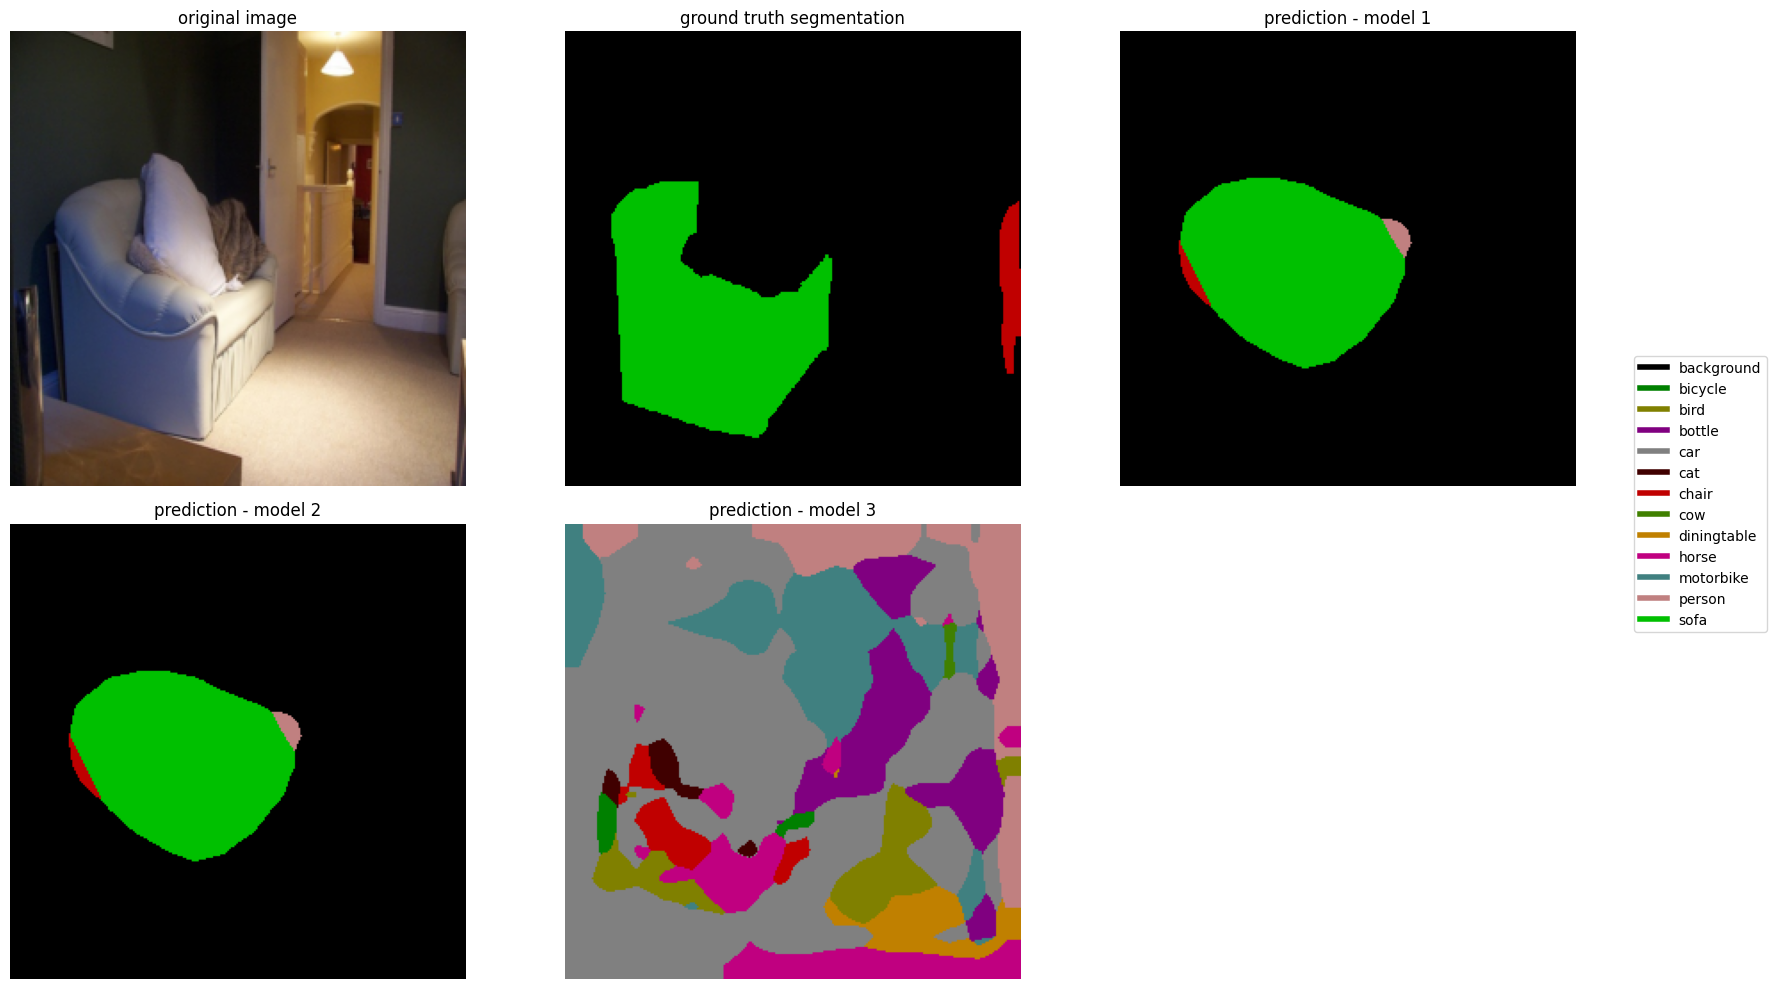

In [68]:
sample_idx = 10 # change to see different examples

# fetch ground truth mask
img_t, gt_mask = val_data[sample_idx]   
input_t = img_t.unsqueeze(0).to(device)

# Denormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_disp = (img_t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

model1.eval()
model2.eval()
model3.eval()

with torch.no_grad():
    out1 = model1(input_t)
    out2 = model2(input_t)
    out3 = model3(input_t)

pred1 = torch.argmax(out1, dim=1).cpu().numpy()[0]
pred2 = torch.argmax(out2, dim=1).cpu().numpy()[0]
pred3 = torch.argmax(out3, dim=1).cpu().numpy()[0]

gt_np = gt_mask.cpu().numpy()

fig = plt.figure(figsize=(18, 10))

# 1) Original
ax = fig.add_subplot(2, 3, 1)
ax.set_title("original image")
ax.imshow(img_disp)
ax.axis("off")

# 2) Ground truth
ax = fig.add_subplot(2, 3, 2)
ax.set_title("ground truth segmentation")
ax.imshow(colorize_mask(gt_np))
ax.axis("off")

# 3) Prediction model 1
ax = fig.add_subplot(2, 3, 3)
ax.set_title("prediction - model 1")
ax.imshow(colorize_mask(pred1))
ax.axis("off")

# 4) Prediction model 2
ax = fig.add_subplot(2, 3, 4)
ax.set_title("prediction - model 2")
ax.imshow(colorize_mask(pred2))
ax.axis("off")

# 5) Prediction model 3
ax = fig.add_subplot(2, 3, 5)
ax.set_title("prediction - model 3")
ax.imshow(colorize_mask(pred3))
ax.axis("off")

# legend for present classes
from matplotlib.lines import Line2D
all_labels = np.unique(np.concatenate([
    gt_np[gt_np != 255].ravel(), pred1.ravel(), pred2.ravel(), pred3.ravel()
]))
legend_elements = [
    Line2D([0], [0], color=np.array(palette[label * 3:label * 3 + 3]) / 255, lw=4, label=VOC_CLASSES[label])
    for label in all_labels
    if 0 <= label < len(VOC_CLASSES)
]
fig.legend(handles=legend_elements, loc="center right", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

Just for fun, here is a demonstration of our best model (dinoNuggetsV0.1.1) successfully identifying Yuri Boykov. [4]

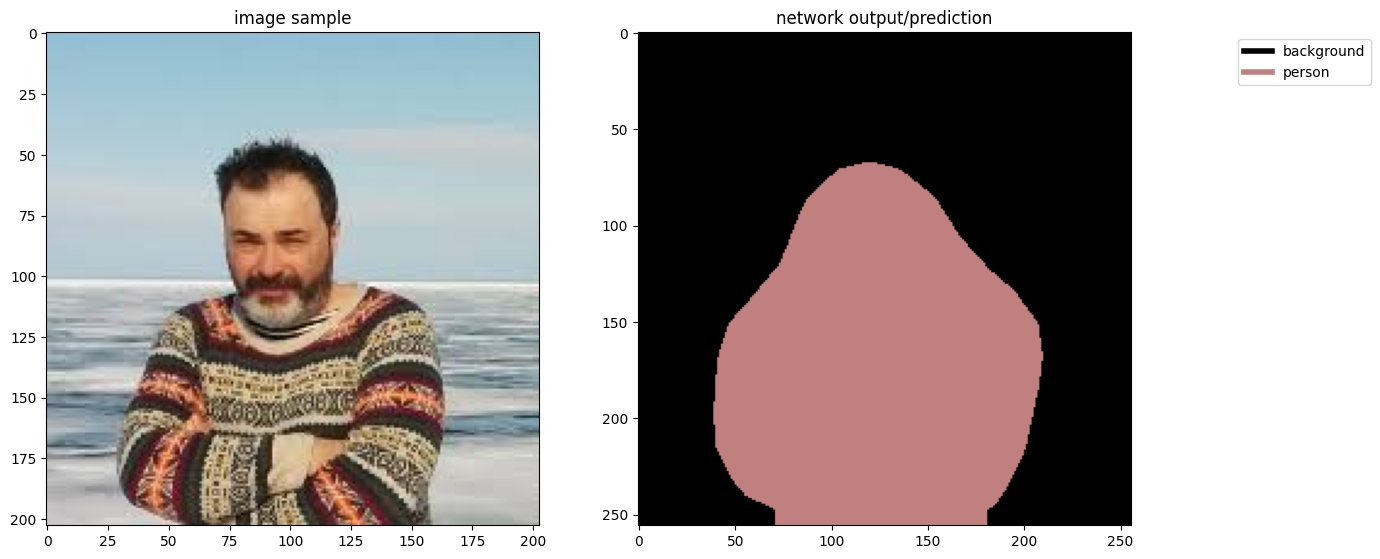

In [90]:
img_path = Path("images") / "yuri.jpg"
yuri = Image.open(img_path).convert("RGB")

model1.eval()

output = model1.forward(val_transforms(yuri).unsqueeze(0).to(device))

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 2, 1)
plt.title('image sample')
ax.imshow(yuri)

ax = fig.add_subplot(1, 2, 2)
plt.title('network output/prediction')

# display the segmentation mask with colorized labels
segmentation_mask = torch.argmax(output, dim=1).cpu().numpy()[0]
ax.imshow(colorize_mask(segmentation_mask))

# add a legend for the classes actually present in the image
from matplotlib.lines import Line2D
unique_labels = np.unique(segmentation_mask)
legend_elements = [
    Line2D([0], [0], color=np.array(palette[label * 3:label * 3 + 3]) / 255, lw=4, label=VOC_CLASSES[label])
    for label in unique_labels if label < len(VOC_CLASSES)
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1))

## Artifacts Analysis

Here, we discuss some common artifacts we encountered during training and why we think they occur. 

One example is that our network sometimes hallucinates objects which are not actually present in the image. For instance, if an image only has a horse, the model will sometimes think that there is a person on top of the horse. We think that this could be due to most training images having people on top of horses so the model picked up on this pattern. 

Another common artifact was strong activation along the top row of the image, even when the objects are not close to it. We are not exactly sure why this happens. We conjecture it is due to many training images (especially those with people are vehicles) having the sky in the top of the image. Perhaps the network was mislead to think that the sky was a part of those classes, leading to strong activations in the pixels where it is usually found. 

Our network is not very good at dealing with birds. On multiple instances of test images with a singular bird, the model likes to classify the entire image as the bird. We believe that this is because birds do not appear often with other classes in the training set. Further, the images that birds do appear in often have noisy backgrounds (complicated nature scenes) that could lead to weak generalization.

## Conclusions



## Citations

1. Kolesnikov, A., & Lampert, C. H. (2016). Seed, Expand and Constrain: Three Principles for Weakly-Supervised Image Segmentation (Version 3). arXiv. https://doi.org/10.48550/ARXIV.1603.06098
2. Oquab, M., Bottou, L., Laptev, I., & Sivic, J. (2015). Is object localization for free? - Weakly-supervised learning with convolutional neural networks. In 2015 IEEE Conference on Computer Vision and Pattern Recognition (CVPR) (pp. 685–694). IEEE. 2015 IEEE Conference on Computer Vision and Pattern Recognition (CVPR). https://doi.org/10.1109/cvpr.2015.7298668
3. Zhou, B., Khosla, A., Lapedriza, A., Oliva, A., & Torralba, A. (2015). Learning Deep Features for Discriminative Localization (Version 1). arXiv. https://doi.org/10.48550/ARXIV.1512.04150
4. Image taken from https://loop.frontiersin.org/people/1108602/overview 